# Exploring a SLAP2 session

SLAP2 (Scanned Line Angular Projection) two-photon imaging from Allen Open
Scope, same stimulus battery as the ecephys and mesoscope sessions.

Two things differ from the mesoscope sessions and shape everything below:

1. **Two DMDs** (`DMD1`, `DMD2`) instead of `VISp_*` planes, each with its own
   ROI set, its own timestamps, and two colour channels — green (iGluSnFR4f,
   glutamate) and red (RCaMP3, calcium).
2. **Imaging is not continuous.** SLAP2 records in bouts of ~30 s separated by
   short blanking periods, so ΔF/F has gaps and only part of each stimulus
   block is covered.

The Zebra noise movie is also stored differently: one interval per repeat in
the `movie` table, not one row per frame.

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append('..')
import utils

In [2]:
path = '../../../rawdata/allen_open_scope/slap2/sub-829704/sub-829704_ses-829704-2025-12-18-10-57-36_image+ophys.nwb'
stream = utils.open_local(path)

print(f'modality      : {stream.modality}')
print(f'session       : {stream.nwb.session_id}')
print(f'subject       : {stream.nwb.subject.subject_id}, {stream.nwb.subject.sex}, {stream.nwb.subject.age}')
print(f'genotype      : {stream.nwb.subject.genotype}')
print(f'processing    : {list(stream.nwb.processing)}')
print(f'DMDs          : {stream.dmds()}')

modality      : slap2
session       : 829704_2025-12-18_10-57-36
subject       : 829704, M, P234D
genotype      : wt/wt
processing    : ['eye_tracking', 'ophys', 'running']
DMDs          : ['DMD1', 'DMD2']


In [3]:
stream.nwb

Data type,int16
Shape,"(4419530,)"
Array size,8.43 MiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),8839060
Compressed size (bytes),8839060
Compression ratio,1.0
Data type,float64
Shape,"(4419530,)"


## Imaging planes and ROIs

In [3]:
for dmd in stream.dmds():
    plane = stream.nwb.imaging_planes[f'ImagingPlane_{dmd}']
    print(f'{dmd}: {plane.location}, {plane.indicator}, '
          f'{plane.imaging_rate:.1f} Hz nominal, '
          f'{len(stream.slap2_rois(dmd))} ROIs')

DMD1: VISp, iGluSnFR4f, RCaMP3, 107.4 Hz nominal, 50 ROIs
DMD2: VISp, iGluSnFR4f, RCaMP3, 143.0 Hz nominal, 75 ROIs


In [4]:
rois = stream.slap2_rois('DMD1')
rois.drop(columns='pixel_mask').head()

,roi_id,n_pixels,x,y,z_min,z_max
0,0,109,330.699806,58.822065,0,0
1,1,109,316.267299,66.220768,0,0
2,2,194,237.163300,107.247955,0,0
3,3,194,242.038606,109.176614,0,0
4,4,194,233.240805,112.247275,0,0


SLAP2 only scans selected lines, so ~94 % of the field of view is never
sampled and comes back as NaN. The images below show the scanned strips only.

DMD1: 94 % of the FOV never scanned
DMD2: 94 % of the FOV never scanned


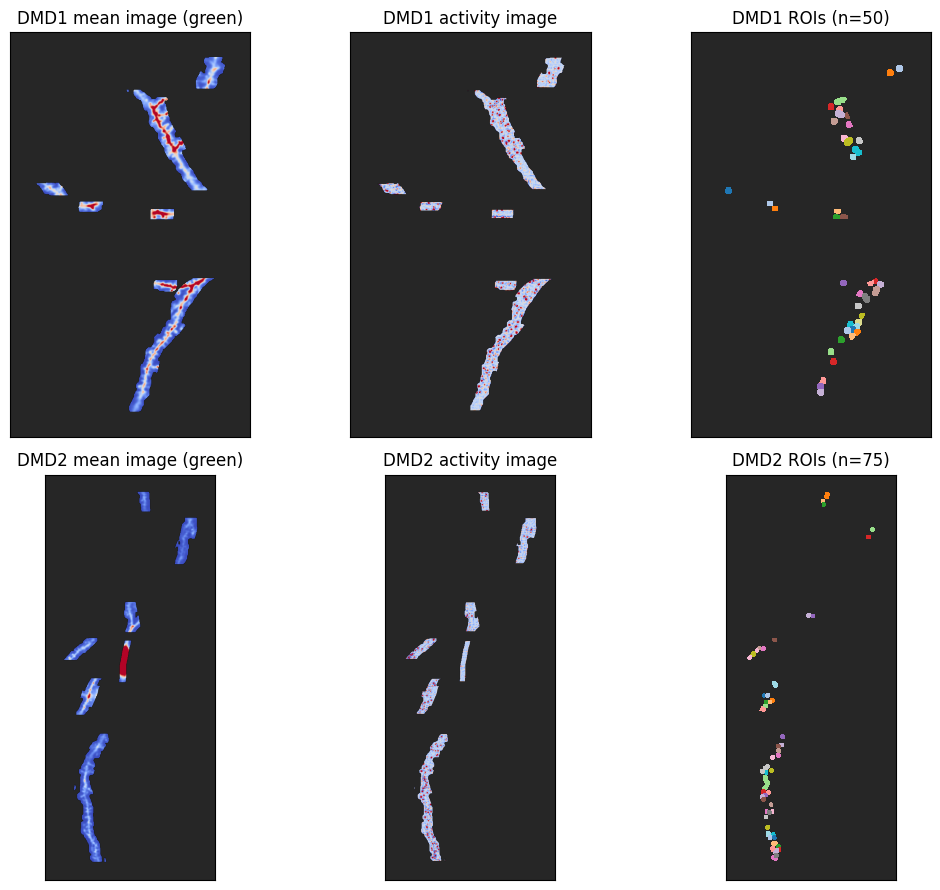

In [36]:
f, axs = plt.subplots(2, 3, figsize=(11, 9))

for row, dmd in zip(axs, stream.dmds()):
    mean     = stream.slap2_mean_image(dmd, channel=0)
    activity = stream.slap2_activity_image(dmd)
    labels   = stream.slap2_roi_labels(dmd)

    # both images have a long bright tail, so clip at the 2nd/95th percentile
    lo, hi = np.nanpercentile(mean, [2, 95])
    # lo, hi = np.nanpercentile(mean, [0, 100])
    row[0].imshow(mean, cmap='coolwarm', vmin=lo, vmax=hi)
    row[0].set_title(f'{dmd} mean image (green)')

    lo, hi = np.nanpercentile(activity, [2, 95])
    row[1].imshow(activity, cmap='coolwarm', vmin=lo, vmax=hi)
    row[1].set_title(f'{dmd} activity image')

    row[2].imshow(np.ma.masked_where(labels == 0, labels % 20), cmap='tab20',
                  interpolation='nearest')
    row[2].set_title(f'{dmd} ROIs (n={labels.max()})')

    print(f'{dmd}: {100 * np.isnan(mean).mean():.0f} % of the FOV never scanned')

for ax in axs.flatten():
    ax.set_facecolor('.15')
    ax.set_xticks([]); ax.set_yticks([])
f.tight_layout()

## Acquisition segments — the SLAP2 duty cycle

The timestamps are not evenly spaced across the session: imaging comes in
bouts. `slap2_segments()` recovers them from the gaps.

In [6]:
segments = stream.slap2_segments('DMD1')
print(f'{len(segments)} segments, '
      f'{segments.duration.median():.1f} s median duration, '
      f'{segments.duration.sum():.0f} s imaged out of '
      f'{segments.stop_time.max() - segments.start_time.min():.0f} s session')
segments.head()

147 segments, 29.4 s median duration, 4292 s imaged out of 4378 s session


,start_time,stop_time,duration,n_samples,i_start,i_stop
0,40.798080,59.829213,19.031133,3806,0,3805
1,60.421056,89.824317,29.403261,5881,3806,9686
2,90.413088,119.835005,29.421917,5885,9687,15571
3,120.413056,149.834973,29.421917,5885,15572,21456
4,150.414080,179.835997,29.421917,5882,21457,27338


In [7]:
for dmd in stream.dmds():
    ts = stream.nwb.processing['ophys'][f'Fluorescence_{dmd}'][f'{dmd}_dFF_green'].timestamps[:]
    dt = np.diff(ts)
    dt = dt[dt < 0.05]   # drop the between-segment gaps
    print(f'{dmd}: effective sampling rate {1 / np.median(dt):.1f} Hz '
          f'(nominal {stream.nwb.imaging_planes[f"ImagingPlane_{dmd}"].imaging_rate:.1f} Hz)')

DMD1: effective sampling rate 214.8 Hz (nominal 107.4 Hz)
DMD2: effective sampling rate 201.5 Hz (nominal 143.0 Hz)


## Session timeline

Each stimulus block is a separate interval table. `slap2_trial_idx == -1`
marks presentations that fall outside any imaging bout.

In [8]:
blocks = []
for name in stream.stim_tables():
    df = stream.stim_df(name)
    blocks.append({
        'table':      name,
        'n_trials':   len(df),
        'start':      df.start_time.min(),
        'stop':       df.stop_time.max(),
        'not_imaged': int((df.slap2_trial_idx == -1).sum()),
    })
blocks = pd.DataFrame(blocks).sort_values('start').reset_index(drop=True)
blocks

,table,n_trials,start,stop,not_imaged
0,standard_control,1088,41.920992,2416.835000,23
1,jitter_oddball,2274,422.772992,2035.998008,48
2,sequential_control_block,1120,2416.848000,2715.468016,24
3,jitter_control,368,2715.828000,3100.299000,10
4,open_loop_prerecorded,11520,3100.310016,3494.501333,213
5,movie,3,3494.508000,4094.496000,0
6,rf_mapping,1215,4094.499008,4418.454992,22


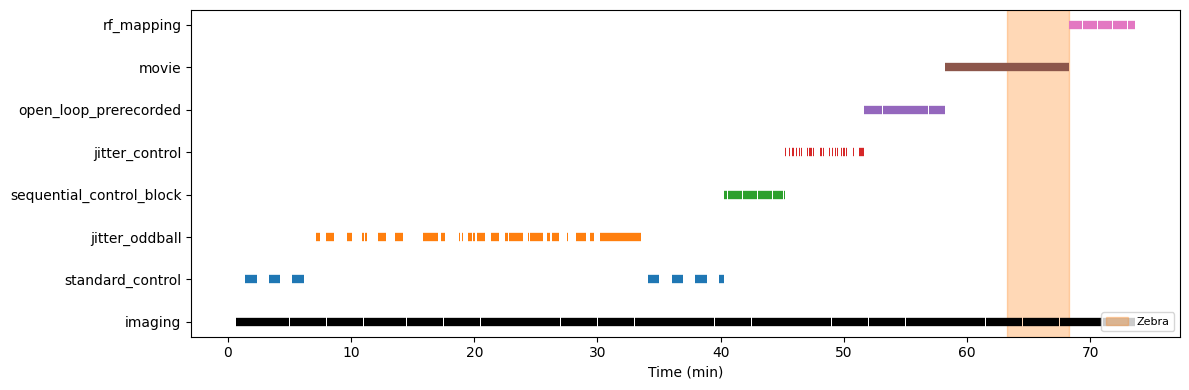

In [9]:
f, ax = plt.subplots(figsize=(12, 4))

# every presentation of every table on its own lane — the blocks interleave,
# so a single lane would hide the nesting
for i, b in blocks.iterrows():
    df = stream.stim_df(b.table)
    ax.hlines([i] * len(df), df.start_time / 60, df.stop_time / 60,
              color=f'C{i}', lw=6)

for seg in segments.itertuples():
    ax.hlines(-1, seg.start_time / 60, seg.stop_time / 60, color='k', lw=6)

for z in stream.zebra_df().itertuples():
    ax.axvspan(z.start_time / 60, z.stop_time / 60, color='tab:orange',
               alpha=.3, zorder=0, label='Zebra')

ax.set_yticks(range(-1, len(blocks)), ['imaging'] + list(blocks.table))
ax.set_xlabel('Time (min)')
ax.legend(loc='lower right', fontsize=8)
f.tight_layout()

## The Zebra noise block

One 300 s repeat, stored as a single row. The movie runs at 30 Hz, so frame
onsets have to be reconstructed — `zebra_frame_times()` does that.

In [10]:
stream.zebra_df()[['BlockLabel', 'TrialNumber', 'Duration', 'start_time', 'stop_time',
                   'slap2_trial_idx']]

,BlockLabel,TrialNumber,Duration,start_time,stop_time,slap2_trial_idx
0,Zebra,16373,300.0,3794.496,4094.496,126


In [11]:
zebra_frames = stream.zebra_frame_times(fps=30.)
print(f'{len(zebra_frames)} frames')
zebra_frames.head()

9000 frames


,TrialNumber,frame,start_time,stop_time
0,16373,0,3794.496000,3794.529333
1,16373,1,3794.529333,3794.562667
2,16373,2,3794.562667,3794.596000
3,16373,3,3794.596000,3794.629333
4,16373,4,3794.629333,3794.662667


In [12]:
zebra_onsets = zebra_frames.start_time.values
t0, t1 = zebra_onsets[0], zebra_frames.stop_time.values[-1]

dff = stream.slap2_dff('DMD1', channel='green', t_start=t0, t_stop=t1)
times = dff.columns.to_numpy()

print(f'ΔF/F during Zebra: {dff.shape[0]} ROIs x {dff.shape[1]} samples')
print(f'{len(times) / len(zebra_onsets):.1f} imaging samples per movie frame')

ΔF/F during Zebra: 50 ROIs x 58829 samples
6.5 imaging samples per movie frame


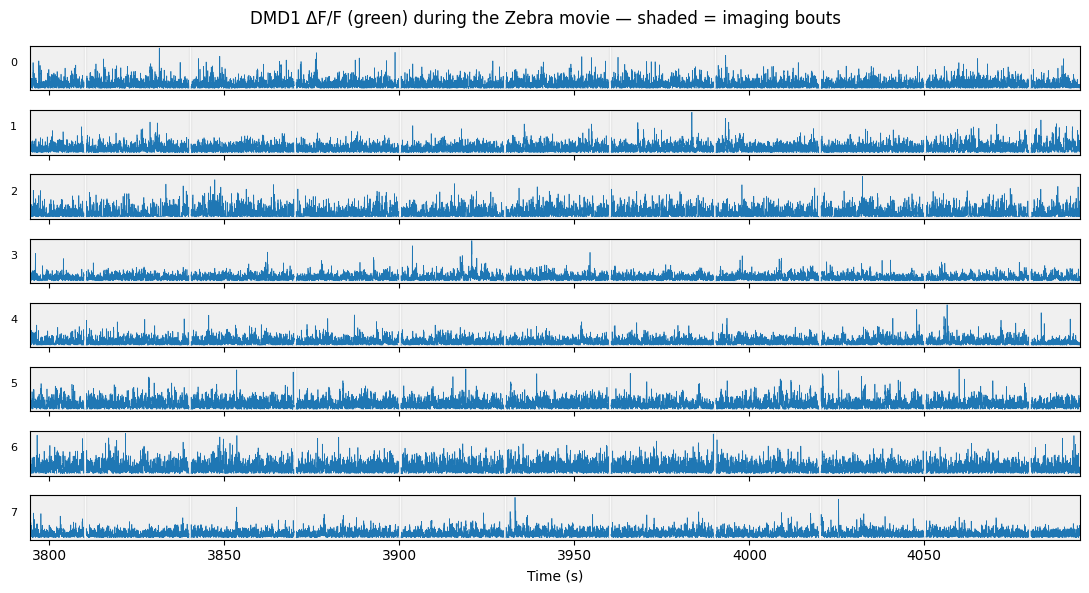

In [38]:
f, axs = plt.subplots(8, 1, figsize=(11, 6), sharex=True)

for i, ax in enumerate(axs):
    ax.plot(times, dff.loc[i].values, lw=.5)
    ax.set_ylabel(f'{i}', rotation=0, labelpad=12, fontsize=8)
    ax.set_yticks([])

for s in segments.query('stop_time > @t0 and start_time < @t1').itertuples():
    for ax in axs:
        ax.axvspan(s.start_time, s.stop_time, color='k', alpha=.06, zorder=0)

axs[-1].set_xlabel('Time (s)')
axs[-1].set_xlim(t0, t1)
f.suptitle('DMD1 ΔF/F (green) during the Zebra movie — shaded = imaging bouts')
f.tight_layout()

## Averaging ΔF/F per movie frame

Same reduction as the mesoscope notebook: for every movie frame take the mean
ΔF/F in a window `[onset + delay, onset + delay + duration]`. Here the imaging
rate is well above the 30 Hz frame rate, so each frame gets several samples.

Frames that fall into a blanking gap have no samples — those come back as NaN
and have to be dropped before correlating against the wavelet decomposition.

In [14]:
def compute_mean_signal_to_zebra_frames(frame_onset_times, signal, delay=0.0, duration=1/30):
    """Mean of each ROI's signal in a window after every frame onset.

    signal: DataFrame (n_rois, n_times) with timestamps as columns.
    Returns (n_rois, n_frames); NaN where no sample falls in the window.
    """
    starts = frame_onset_times + delay
    stops  = starts + duration

    times   = signal.columns.to_numpy()
    signals = signal.to_numpy()

    idx_starts = np.searchsorted(times, starts)
    idx_stops  = np.searchsorted(times, stops)

    out = np.full((signals.shape[0], len(frame_onset_times)), np.nan)
    with warnings.catch_warnings():
        # ROIs can be NaN for a whole window; that is the answer, not a problem
        warnings.simplefilter('ignore', RuntimeWarning)
        for k, (s, e) in enumerate(zip(idx_starts, idx_stops)):
            if e > s:
                out[:, k] = np.nanmean(signals[:, s:e], axis=1)
    return out

means_to_onsets = compute_mean_signal_to_zebra_frames(zebra_onsets, dff)
covered = ~np.isnan(means_to_onsets).all(axis=0)

print(f'{means_to_onsets.shape[1]} frames, {covered.sum()} with imaging '
      f'({100 * covered.mean():.0f} %)')

9000 frames, 8798 with imaging (98 %)


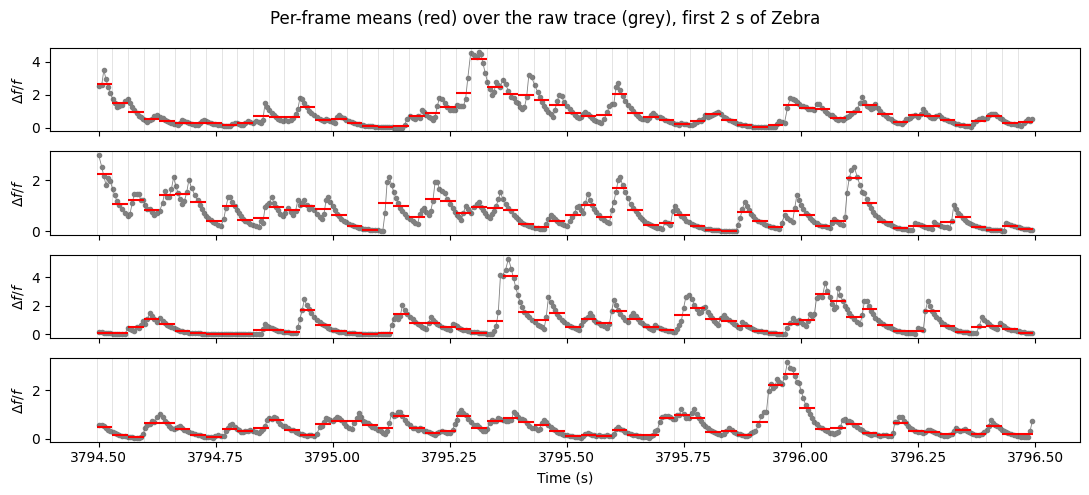

In [15]:
f, axs = plt.subplots(4, 1, figsize=(11, 5), sharex=True)

N = 60   # frames to zoom in on
window = (times > zebra_onsets[0]) & (times < zebra_onsets[N])

for i, ax in enumerate(axs):
    ax.plot(times[window], dff.loc[i].values[window], lw=.6, color='.5', marker='.')
    ax.hlines(means_to_onsets[i, :N], zebra_onsets[:N], zebra_onsets[:N] + 1/30,
              colors='r')
    ax.set_ylabel('$\\Delta f/f$')

for ax in axs:
    for onset in zebra_onsets[:N]:
        ax.axvline(onset, color='k', alpha=.15, lw=.5)

axs[-1].set_xlabel('Time (s)')
f.suptitle('Per-frame means (red) over the raw trace (grey), first 2 s of Zebra')
f.tight_layout()

The frame-averaged matrix lines up with the wavelet decomposition of the same
movie, which is what the waven pipeline correlates against.

In [16]:
path_stim = '../../../rawdata/allen_open_scope/stimulus/zebra/zebra_allen_screen_tscale_30_scale_10_downsampled__85_107.npy'
movie = np.load(path_stim, mmap_mode='r')

print(f'movie          : {movie.shape}  (frames, ny, nx)')
print(f'frame onsets   : {len(zebra_onsets)}')
print(f'means_to_onsets: {means_to_onsets.shape}')

movie          : (9000, 85, 107)  (frames, ny, nx)
frame onsets   : 9000
means_to_onsets: (50, 9000)


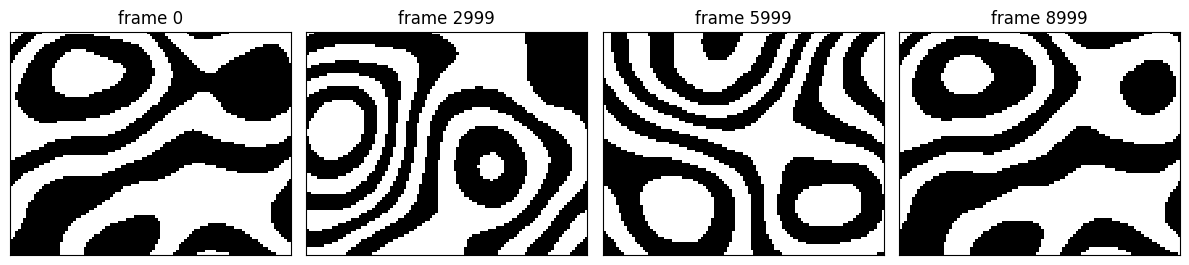

In [17]:
f, axs = plt.subplots(1, 4, figsize=(12, 3))
for ax, k in zip(axs, np.linspace(0, len(movie) - 1, 4).astype(int)):
    ax.imshow(movie[k], cmap='gray', interpolation='nearest')
    ax.set_title(f'frame {k}')
    ax.set_xticks([]); ax.set_yticks([])
f.tight_layout()

## RF mapping block

Gabor patches on a 9 x 9 grid, three orientations, 0.25 s each, 15 repeats per
grid position. The obvious thing to try is a receptive field per ROI straight
from the trial averages — no wavelet detour.

In [18]:
rf = stream.stim_df('rf_mapping')
print(f'{len(rf)} presentations\n'
      f'X            : {np.sort(rf.X.unique())}\n'
      f'Y            : {np.sort(rf.Y.unique())}\n'
      f'orientations : {np.degrees(np.sort(rf.Orientation.unique())).round(1)} deg')
rf[['X', 'Y', 'Orientation', 'Duration', 'start_time', 'slap2_trial_idx']].head()

1215 presentations
X            : [-40 -30 -20 -10   0  10  20  30  40]
Y            : [-40 -30 -20 -10   0  10  20  30  40]
orientations : [ 0. 45. 90.] deg


,X,Y,Orientation,Duration,start_time,slap2_trial_idx
id,,,,,,
0,0,20,0.000000,0.25,4094.499008,136
1,30,30,0.000000,0.25,4094.758016,136
2,10,30,1.570796,0.25,4095.024992,136
3,10,-20,0.785398,0.25,4095.291008,136
4,40,0,0.000000,0.25,4095.558016,136


In [19]:
dff_rf = stream.slap2_dff('DMD1', channel='green',
                          t_start=rf.start_time.min() - 1, t_stop=rf.stop_time.max())

resp = compute_mean_signal_to_zebra_frames(
    rf.start_time.values, dff_rf, delay=0.05, duration=0.25)
base = compute_mean_signal_to_zebra_frames(
    rf.start_time.values, dff_rf, delay=-0.30, duration=0.25)

rf_resp = resp - base
print(f'{np.isfinite(rf_resp).all(axis=0).sum()} of {len(rf)} presentations imaged')

1182 of 1215 presentations imaged


In [20]:
def rf_maps(response, trials, reps=slice(None)):
    """Average `response` (n_rois, n_trials) into a (n_rois, ny, nx) grid map."""
    xs, ys = np.sort(trials.X.unique()), np.sort(trials.Y.unique())
    maps = np.full((response.shape[0], len(ys), len(xs)), np.nan)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        for iy, y in enumerate(ys):
            for ix, x in enumerate(xs):
                sel = np.where(((trials.X == x) & (trials.Y == y)).values)[0]
                maps[:, iy, ix] = np.nanmean(response[:, sel[reps]], axis=1)
    return maps, xs, ys

maps, xs, ys = rf_maps(rf_resp, rf)
maps.shape

(50, 9, 9)

Before reading anything into those maps: are they reliable? Split the 15
repeats per position into two halves and correlate the two resulting maps.

In [21]:
half_a, _, _ = rf_maps(rf_resp, rf, reps=slice(0, None, 2))
half_b, _, _ = rf_maps(rf_resp, rf, reps=slice(1, None, 2))

split_half = np.array([
    np.corrcoef(a.ravel(), b.ravel())[0, 1]
    for a, b in zip(half_a, half_b)
])

print(f'split-half r: median {np.nanmedian(split_half):+.3f}, '
      f'mean {np.nanmean(split_half):+.3f}, max {np.nanmax(split_half):+.3f}')
print(f'{np.mean(split_half > .3):.0%} of ROIs above r = 0.3')

split-half r: median -0.000, mean +0.020, max +0.631
4% of ROIs above r = 0.3


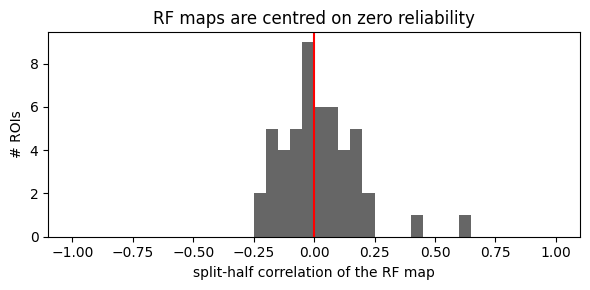

In [22]:
f, ax = plt.subplots(figsize=(6, 3))
ax.hist(split_half, bins=np.linspace(-1, 1, 41), color='.4')
ax.axvline(0, color='r')
ax.set_xlabel('split-half correlation of the RF map')
ax.set_ylabel('# ROIs')
ax.set_title('RF maps are centred on zero reliability')
f.tight_layout()

The distribution sits on zero: at 15 repeats per position, a per-ROI RF map
from this block is noise for almost every ROI. The handful in the right tail
are what you would expect from 50 draws. Plotted below for completeness — the
strongest few, ranked by split-half reliability rather than by amplitude,
which would just pick the noisiest ROIs.

This is the argument for the wavelet approach on the Zebra block: 9000 frames
of a broadband movie carry far more constraint than 1215 patch presentations.

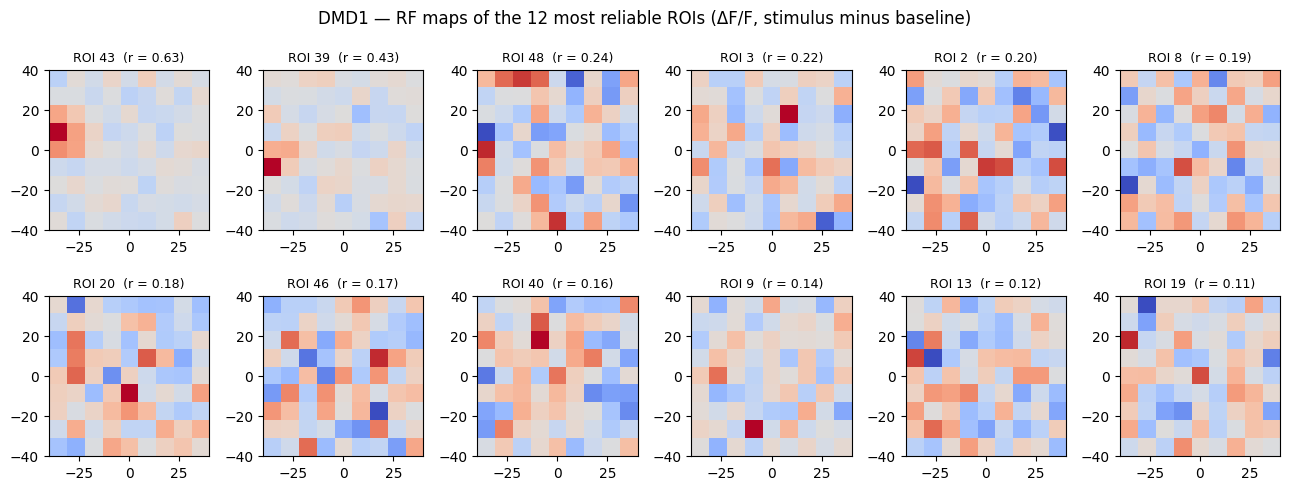

In [23]:
order = np.argsort(split_half)[::-1]

f, axs = plt.subplots(2, 6, figsize=(13, 5))
for ax, i in zip(axs.flatten(), order):
    m = maps[i]
    v = np.nanmax(np.abs(m))
    ax.imshow(m, cmap='coolwarm', vmin=-v, vmax=v, origin='lower',
              extent=[xs.min(), xs.max(), ys.min(), ys.max()])
    ax.set_title(f'ROI {i}  (r = {split_half[i]:.2f})', fontsize=9)
f.suptitle('DMD1 — RF maps of the 12 most reliable ROIs (ΔF/F, stimulus minus baseline)')
f.tight_layout()

## Behaviour during the Zebra block

Running is sampled at ~1 kHz off the wheel encoder, so it needs binning before
it is readable. Eye tracking in this session is largely unusable: 81 % of
frames are flagged as likely blinks, and `pupil.area` uses -1 rather than NaN
for frames with no fit — use `area_raw` masked by the blink flag.

In [24]:
running = stream.running_df()
pupil   = stream.pupil_df()

print(f'running: {len(running)} samples at '
      f'{1 / np.median(np.diff(running.time)):.0f} Hz')
print(f'pupil  : {len(pupil)} samples at '
      f'{1 / np.median(np.diff(pupil.timestamps)):.0f} Hz, '
      f'{pupil.blink.mean():.0%} flagged as blinks')

running: 4419528 samples at 1008 Hz
pupil  : 132652 samples at 30 Hz, 81% flagged as blinks


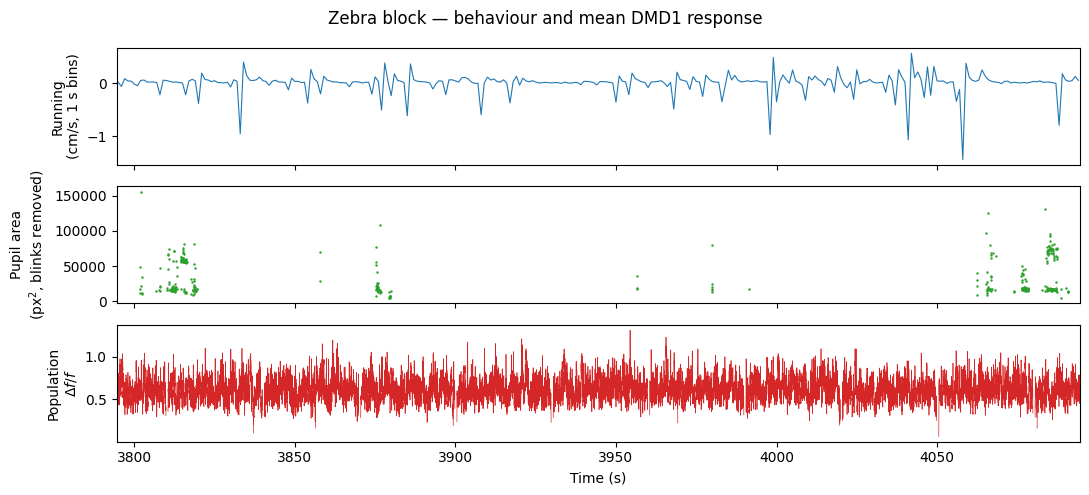

In [25]:
run_win = running[(running.time > t0) & (running.time < t1)]
pup_win = pupil[(pupil.timestamps > t0) & (pupil.timestamps < t1)].copy()
pup_win.loc[pup_win.blink, 'area_raw'] = np.nan

bins    = np.arange(t0, t1, 1.)          # 1 s bins for the encoder trace
run_bin = run_win.groupby(np.digitize(run_win.time, bins)).agg(
    time=('time', 'mean'), speed=('speed', 'mean'))

with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    population = np.nanmean(dff.to_numpy(), axis=0)

f, axs = plt.subplots(3, 1, figsize=(11, 5), sharex=True)

axs[0].plot(run_bin.time, run_bin.speed, lw=.8)
axs[0].set_ylabel('Running\n(cm/s, 1 s bins)')

# scattered, not lined: the surviving frames are sparse and isolated
axs[1].plot(pup_win.timestamps, pup_win.area_raw, ls='none', marker='.', ms=1.5,
            color='tab:green')
axs[1].set_ylabel('Pupil area\n(px$^2$, blinks removed)')

axs[2].plot(times, population, lw=.5, color='tab:red')
axs[2].set_ylabel('Population\n$\\Delta f/f$')
axs[2].set_xlabel('Time (s)')

axs[-1].set_xlim(t0, t1)
f.suptitle('Zebra block — behaviour and mean DMD1 response')
f.tight_layout()

## Raw NWB handle

In [26]:
nwb = stream.nwb
nwb

Data type,int16
Shape,"(4419530,)"
Array size,8.43 MiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),8839060
Compressed size (bytes),8839060
Compression ratio,1.0
Data type,float64
Shape,"(4419530,)"


In [33]:
nwb.processing["ophys"]["ImageSegmentation"][f"PlaneSegmentation_DMD1"].to_dataframe()['pixel_mask'].shape

(50,)